If you lack an adata file, then you can use the following command or visit [this website](https://data.mendeley.com/datasets/hhny5ff7yj/1) to download it.

```bash
mkdir data
wget -O ./data/ebdata_v3.h5ad https://data.mendeley.com/public-files/datasets/hhny5ff7yj/files/d82698f4-d143-442f-9a41-10be8ad02584/file_downloaded

In [62]:
%load_ext autoreload
%autoreload 2
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch

from torchdyn.core import NeuralODE
from tqdm.notebook import tqdm

from scFM_density_estimation.models import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
def prepare_batch(X, C, num_classes, batch_size, device):
    indices = np.random.randint(X.shape[0], size=batch_size)
    x1 = torch.from_numpy(X[indices]).float().to(device)
    cond = torch.nn.functional.one_hot(torch.from_numpy(C[indices]).long(),
                                       num_classes=num_classes).float().to(device)
    return x1, cond

In [2]:
adata = sc.read_h5ad("./data/ebdata_v3.h5ad")

In [3]:
label = "leiden" # sample_labels leiden
n_categories = len(adata.obs[label].unique())

coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords
X = adata.obsm["X_phate_standardized"]
C = adata.obs[label].cat.codes.values

  0%|          | 0/50000 [00:00<?, ?it/s]

10000: loss 0.063


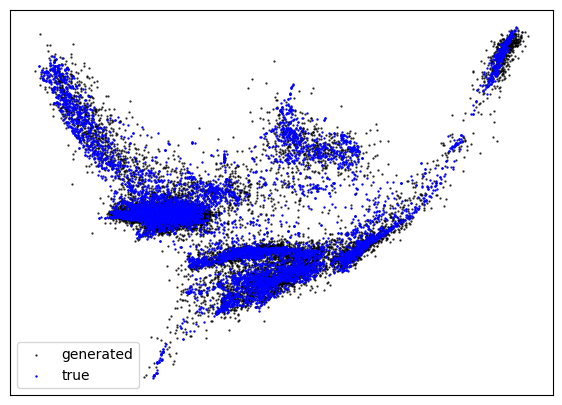

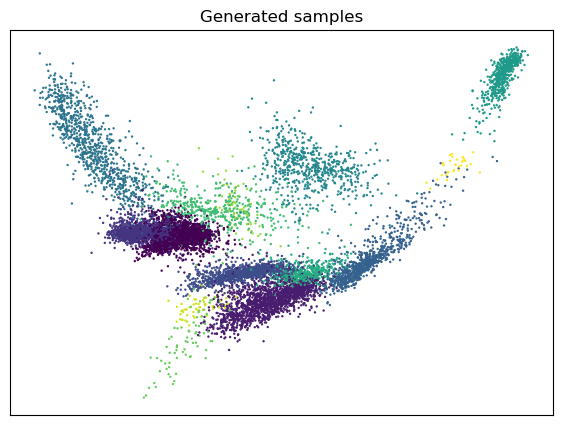

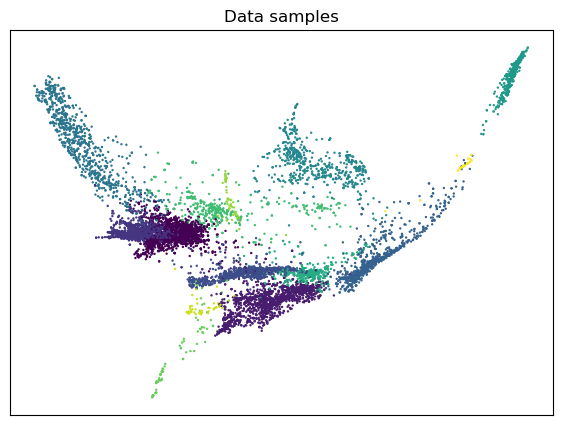

20000: loss 0.052


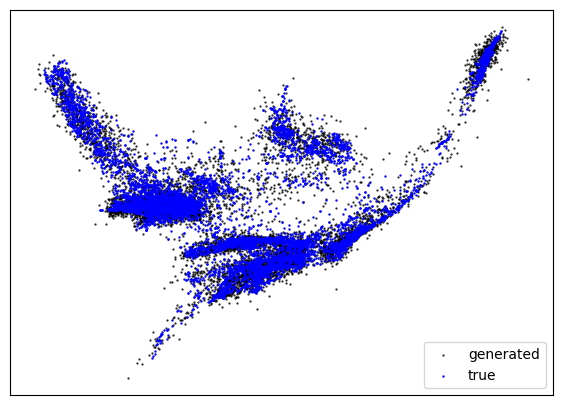

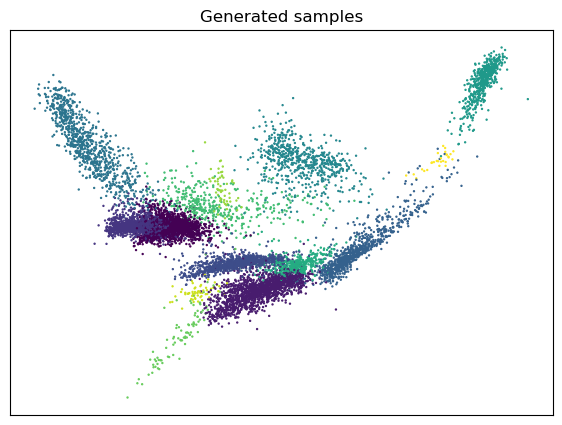

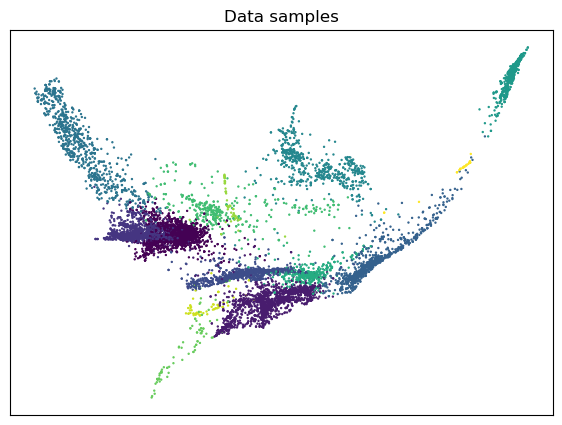

30000: loss 0.079


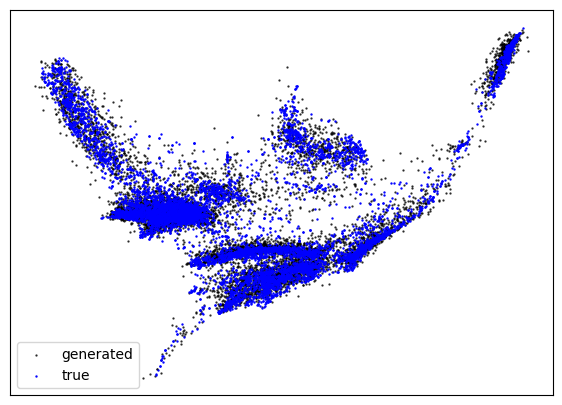

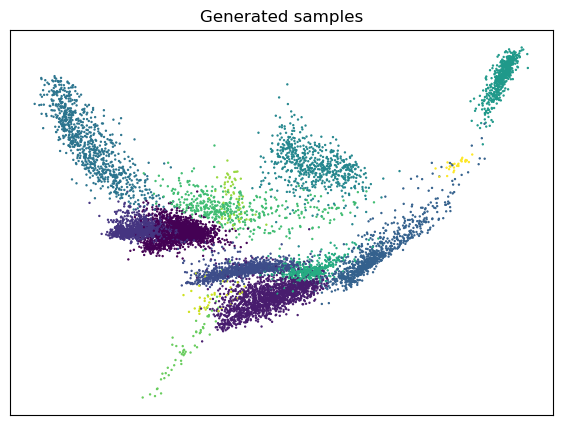

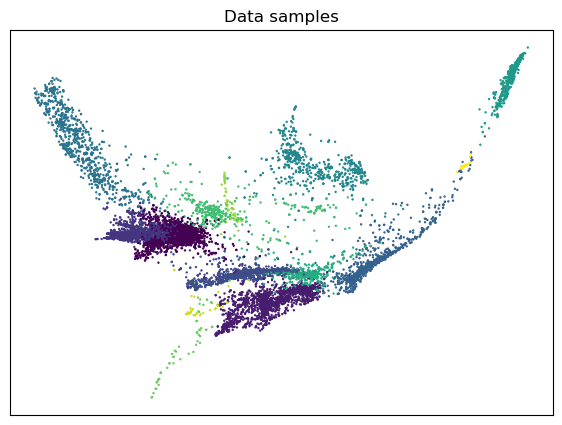

40000: loss 0.076


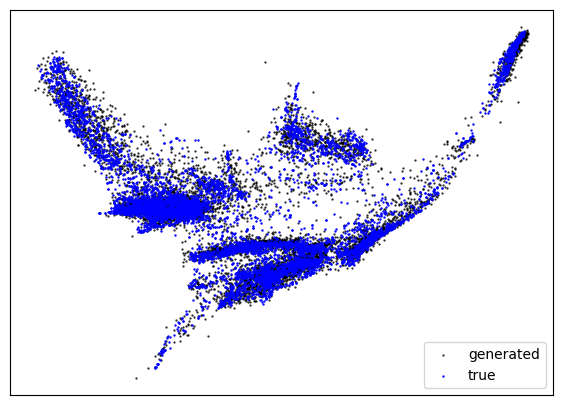

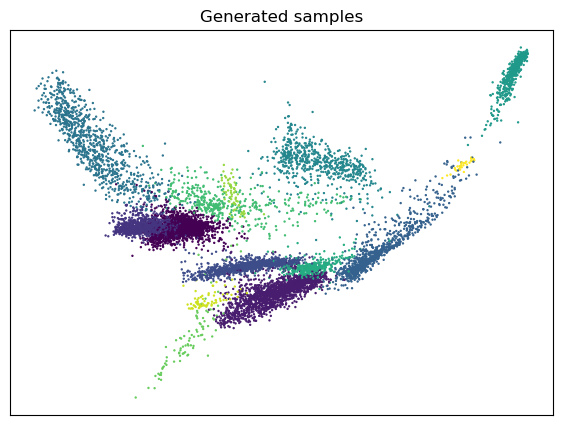

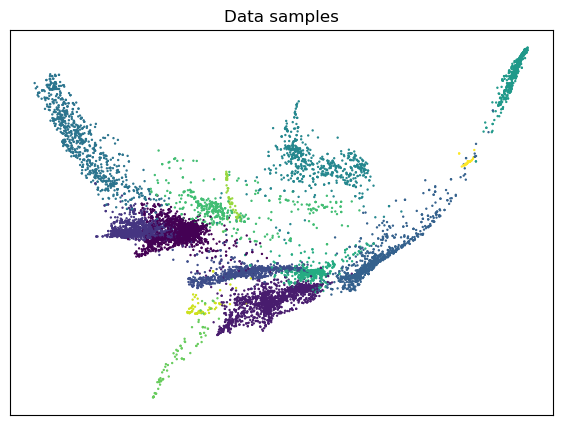

50000: loss 0.072


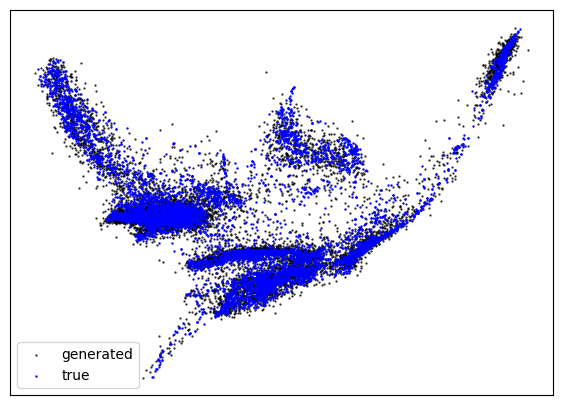

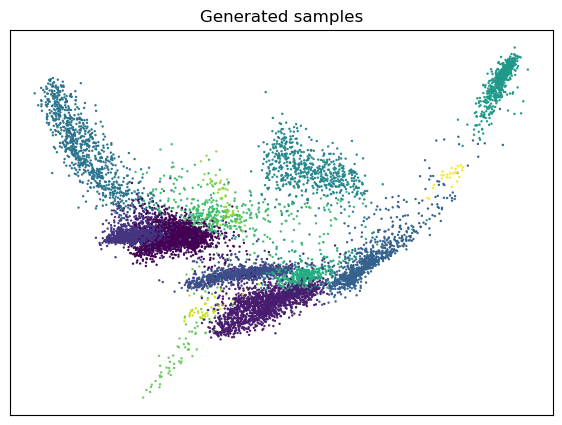

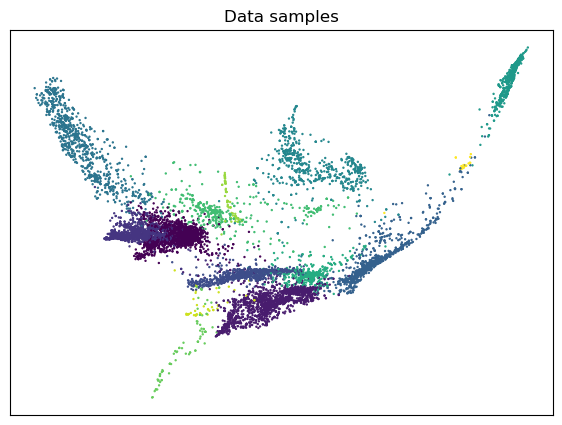

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
sigma = 0.1
dim = 2
cond_dim = np.max(C) + 1
use_ot_sampler = True
model = ConditionalFlowMatching(input_dim=dim, hidden_dims=[64, 64, 64],
                                   cond_dim=cond_dim, use_encoder=False,
                                   use_ot_sampler=use_ot_sampler).to(device)
optimizer = model.configure_optimizers()

for k in tqdm(range(50000)):
    optimizer.zero_grad()

    x1, cond = prepare_batch(X, C, cond_dim, batch_size, device)
    loss = model.shared_step(x1, cond)
    
    loss.backward()
    optimizer.step()

    if (k + 1) % 10000 == 0:
        print(f"{k+1}: loss {loss.item():0.3f}")

        x1, cond = prepare_batch(X, C, cond_dim, 10000, device)
        model.run_simulation(x1, cond, size=0.5, plot_size=(7, 5))

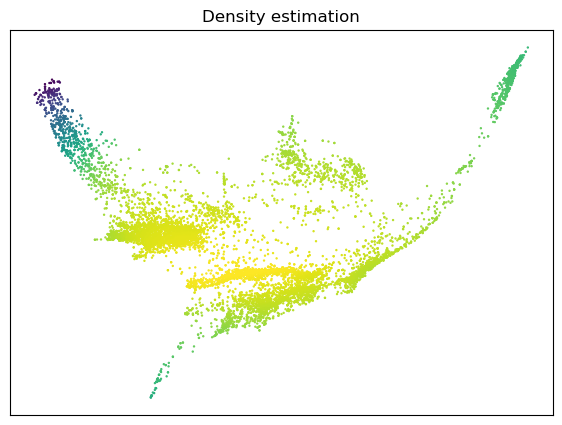

In [61]:
condition = 3
n = 10000
x1, _ = prepare_batch(X, C, cond_dim, n, device)
cond = torch.from_numpy(np.array([1 if i == condition else 0 for i in range(cond_dim)]).reshape(1, -1)
                                ).float().expand(n, cond_dim).to(device)
model.estimate_density(x1, cond, size=0.5, plot_size=(7, 5))

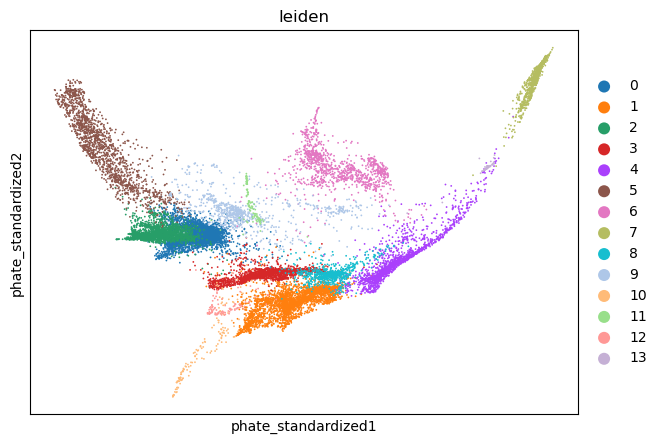

In [28]:
sc.pl.scatter(adata, basis="phate_standardized", color=label)

In [29]:
adata.obs[label].cat.codes.unique()

array([ 4,  7,  8,  6, 13,  9,  3,  1, 11,  5, 10,  0,  2, 12], dtype=int8)